<a href="https://colab.research.google.com/github/aayushchourasia123/Machine-Learning/blob/main/power%20transformation/Power_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

In [112]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [113]:
df=pd.read_csv('/content/concrete_data.csv')

In [114]:
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [115]:
df.shape

(1030, 9)

In [116]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [117]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [118]:
x=df.drop(columns=['Strength'])
y=df.iloc[:,-1]

In [119]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [120]:
#linear regression without transformation
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
r2_score(y_test,y_pred)

0.627553179231485

In [121]:
#cross checking with cross val score
lr=LinearRegression()
np.mean(cross_val_score(lr,x,y,scoring='r2'))

np.float64(0.46099404916628606)

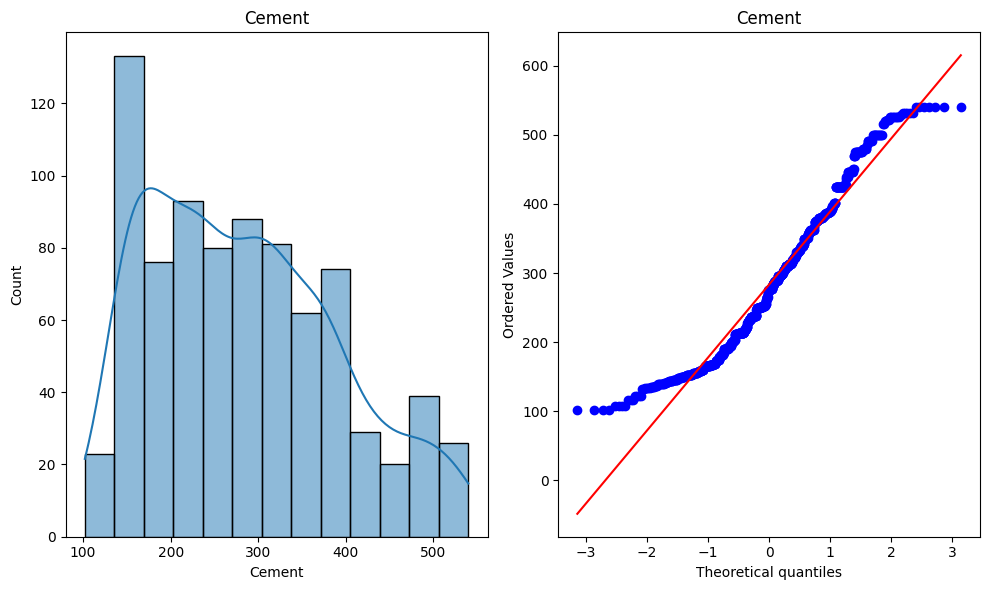

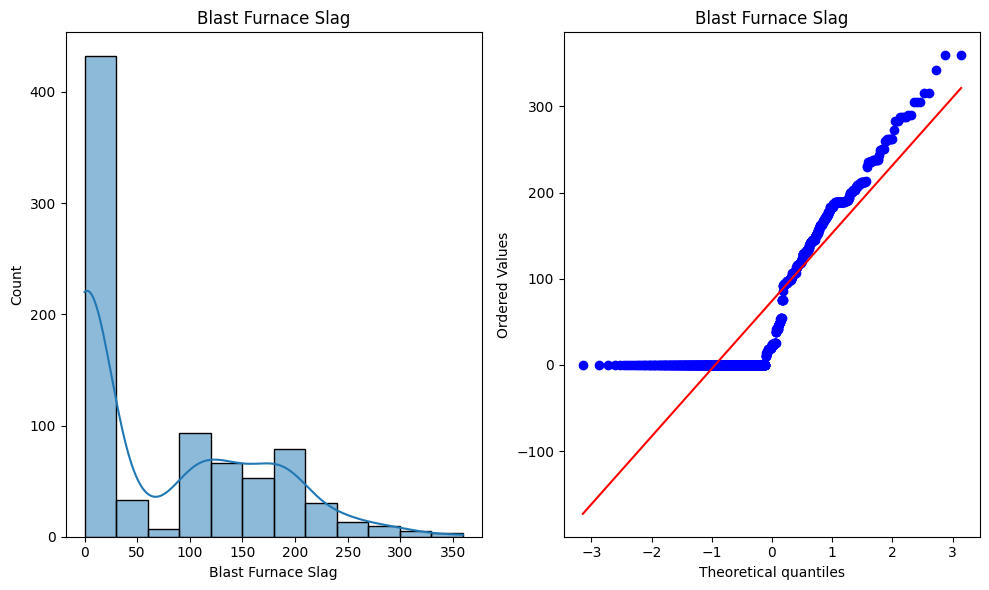

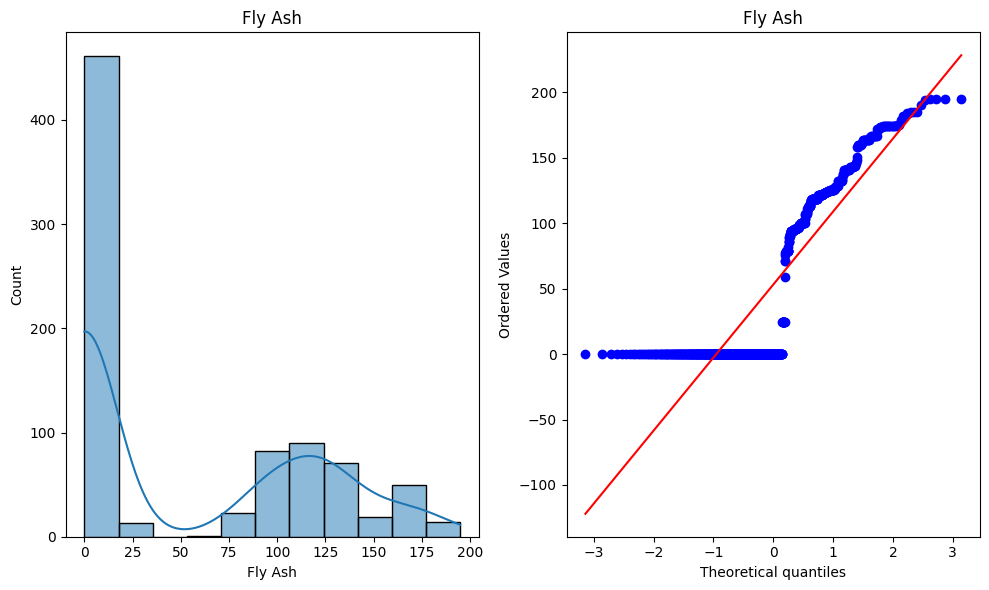

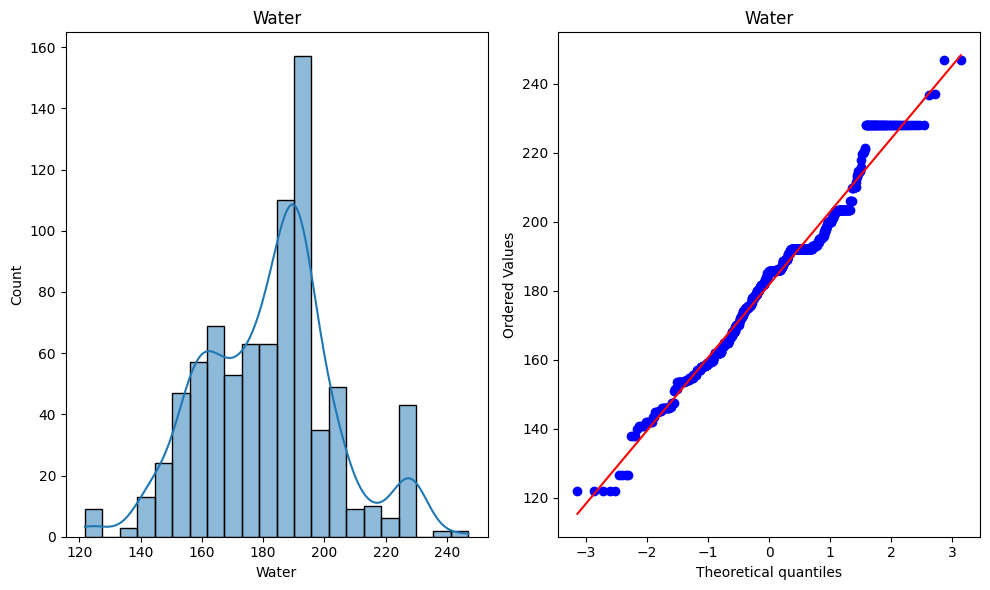

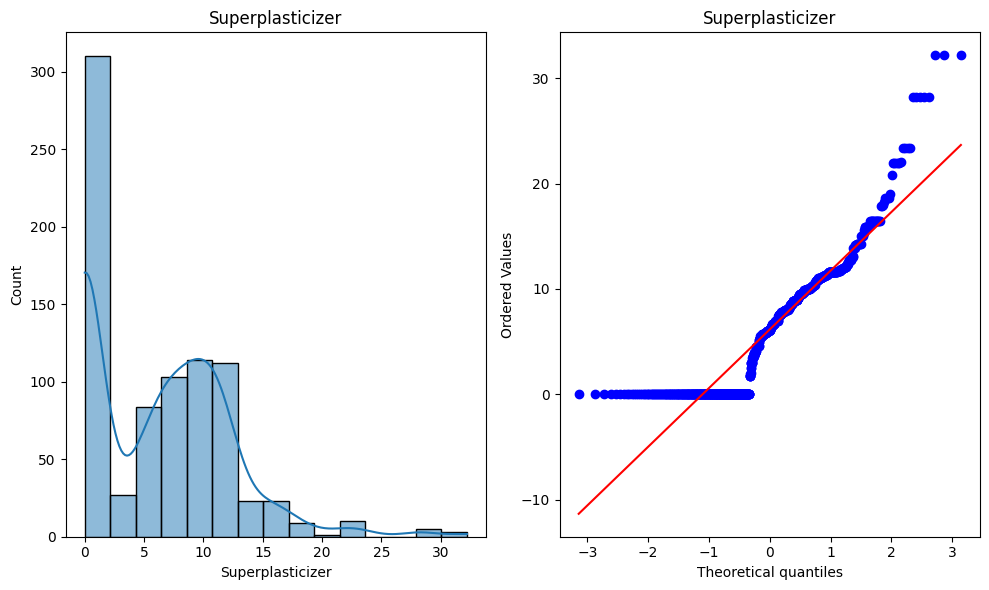

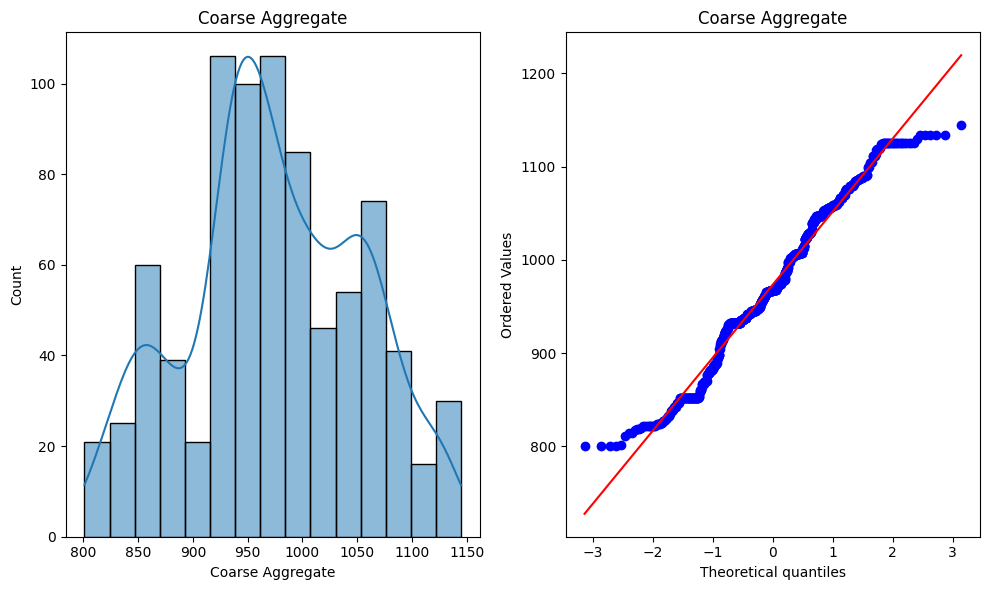

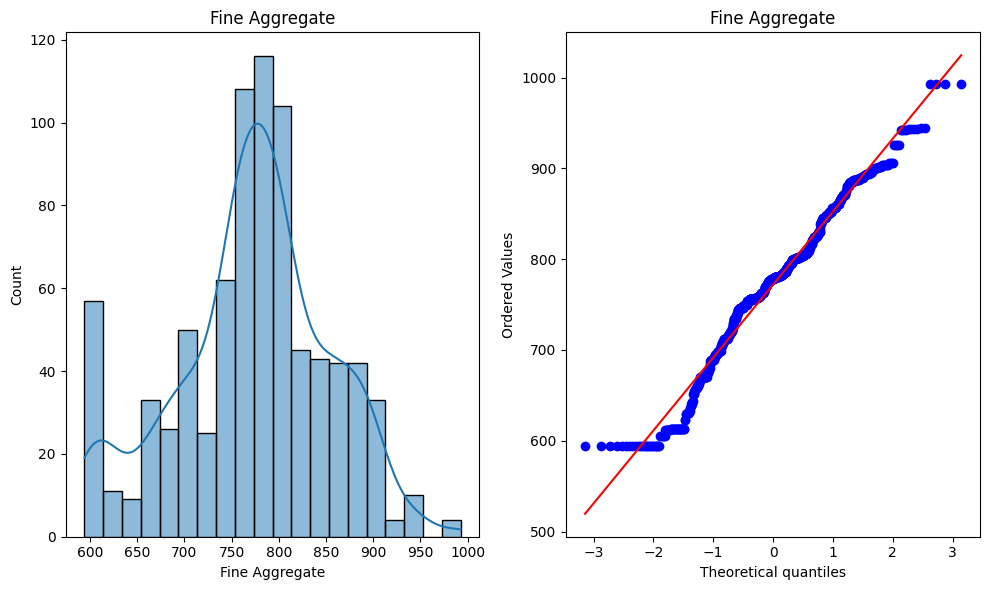

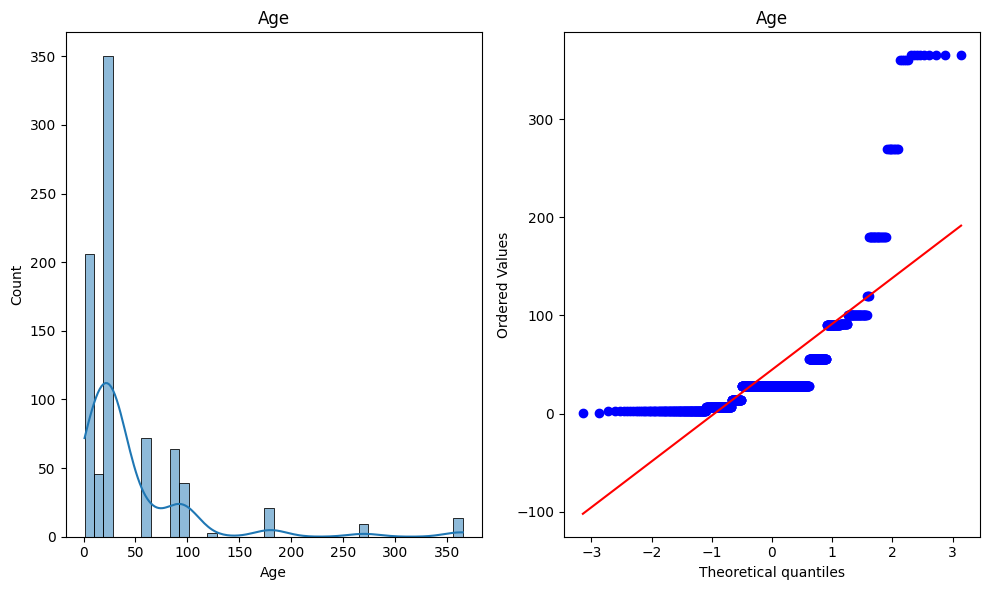

In [122]:
#plotting the histplot without any transformation

for col in x_train.columns:
  plt.figure(figsize=(10,6))
  plt.subplot(1,2,1)
  sns.histplot(x_train[col],kde=True)
  plt.title(col)

  plt.subplot(1,2,2)
  stats.probplot(x_train[col],dist='norm',plot=plt)
  plt.title(col)

  plt.tight_layout()
  plt.show()

In [123]:
#applying box-cox transform
pt=PowerTransformer(method='box-cox')
x_train_transformed=pt.fit_transform(x_train+0.000001) #adding because box-cox only applicable for numbers greater than 0
x_test_transformed=pt.transform(x_test+0.000001)
pd.DataFrame({'cols':x_train.columns,'box_cox_lambda':pt.lambdas_})

,cols,box_cox_lambda
0,Cement,0.177025
1,Blast Furnace Slag,0.025093
2,Fly Ash,-0.038970
3,Water,0.772682
4,Superplasticizer,0.098811
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [124]:
#applying linear regression on transformed data
lr=LinearRegression()
lr.fit(x_train_transformed,y_train)
y_pred=lr.predict(x_test_transformed)
r2_score(y_test,y_pred)

0.8047825011028631

In [125]:
#cross val after transformation
pt=PowerTransformer(method='box-cox')
x_transformed=pt.fit_transform(x+0.000001)

lr=LinearRegression()
np.mean(cross_val_score(lr,x_transformed,y,scoring='r2'))

np.float64(0.6662950328464643)

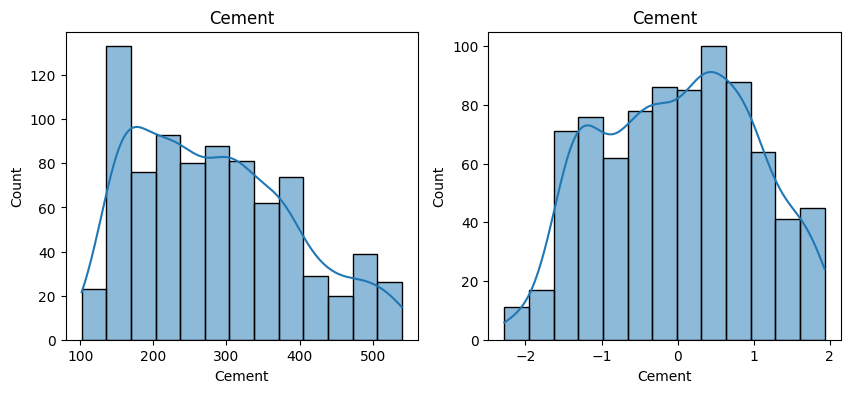

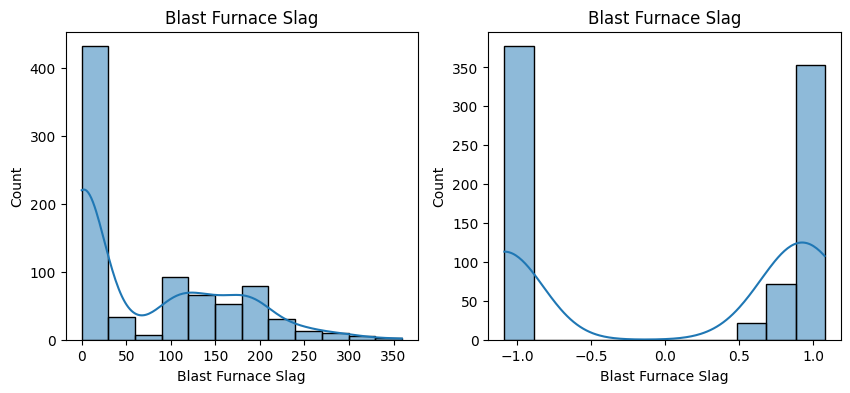

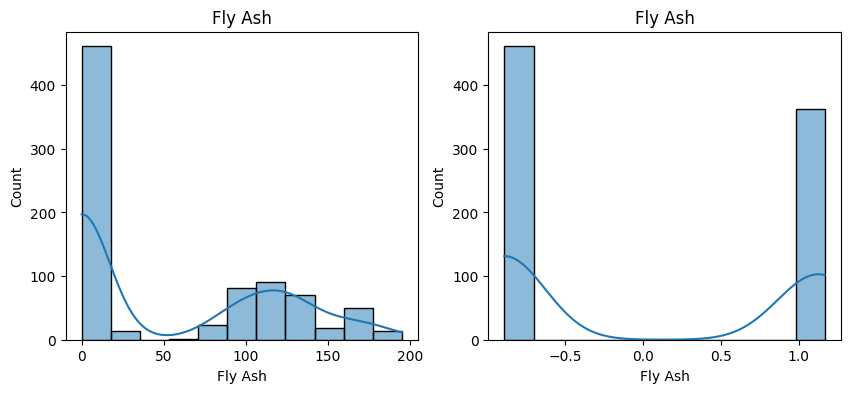

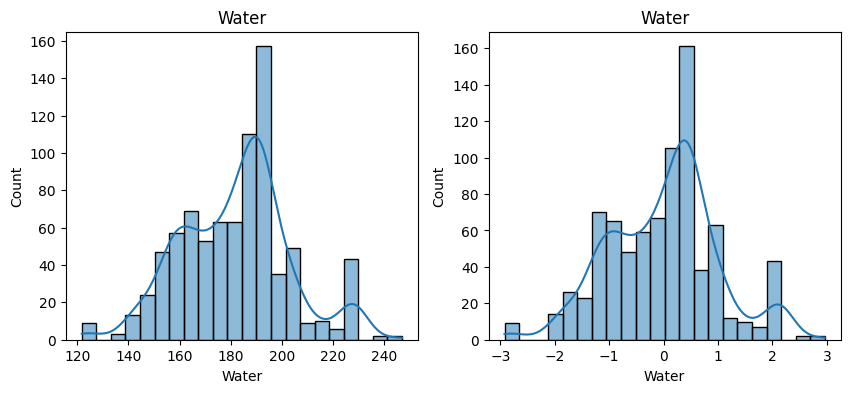

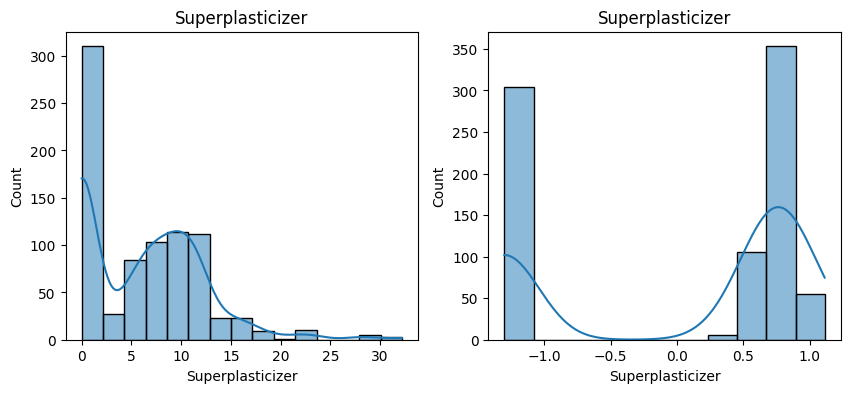

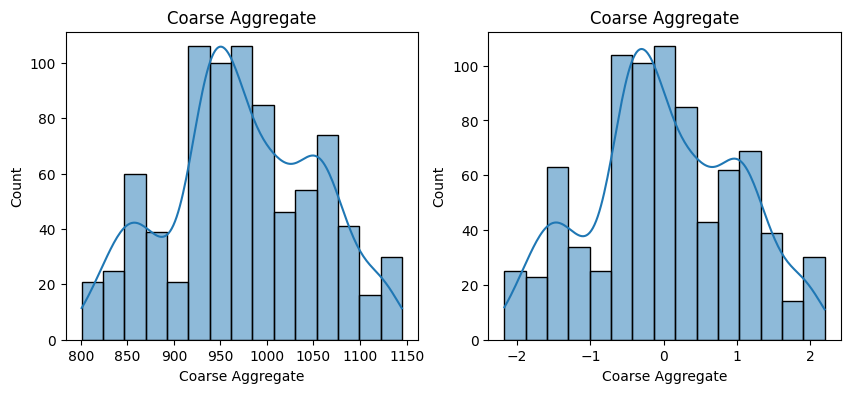

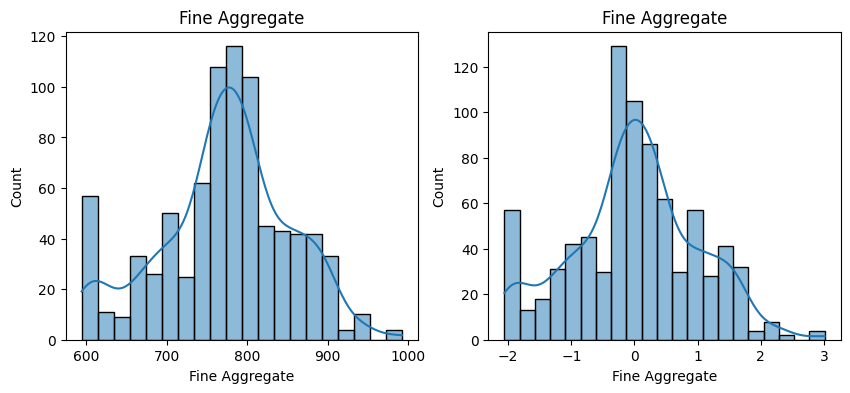

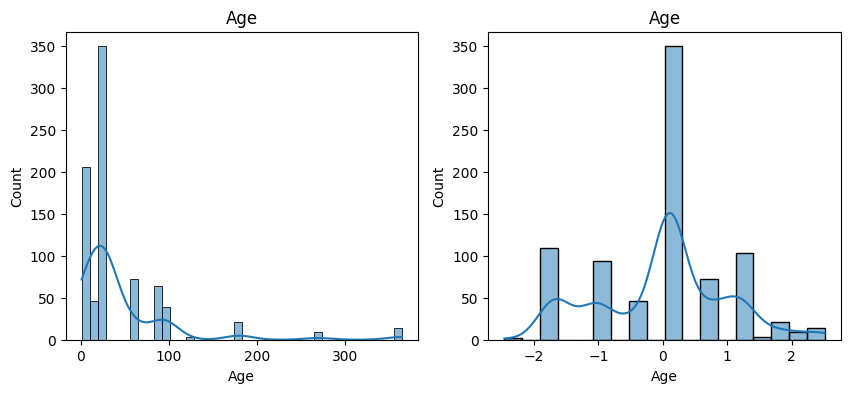

In [126]:
#before and after comparision of box-cox
x_train_transformed = pd.DataFrame(x_train_transformed, columns=x_train.columns)
for cols in x_train_transformed.columns:
  plt.figure(figsize=(10,4))
  plt.subplot(1,2,1)
  sns.histplot(x_train[cols],kde=True)
  plt.title(cols)

  plt.subplot(1,2,2)
  sns.histplot(x_train_transformed[cols],kde=True)
  plt.title(cols)

  plt.show()

In [127]:
#apply yeo-johnson transform
pt1=PowerTransformer()
x_train_transformed2=pt1.fit_transform(x_train)
x_test_transformed2=pt1.transform(x_test)
lr=LinearRegression()
lr.fit(x_train_transformed2,y_train)

y_pred=lr.predict(x_test_transformed2)
print(r2_score(y_test,y_pred))
pd.DataFrame({'cols':x_train.columns,'yeo_johnson_lambda':pt1.lambdas_})

0.8161906512004999


,cols,yeo_johnson_lambda
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [128]:
#applying cross val
pt1=PowerTransformer()
x_transformed2=pt1.fit_transform(x)

lr=LinearRegression()
np.mean(cross_val_score(lr,x_transformed2,y,scoring='r2'))

np.float64(0.6834625141500866)

In [129]:
x_train_transformed2=pd.DataFrame(x_train_transformed2,columns=x_train.columns)

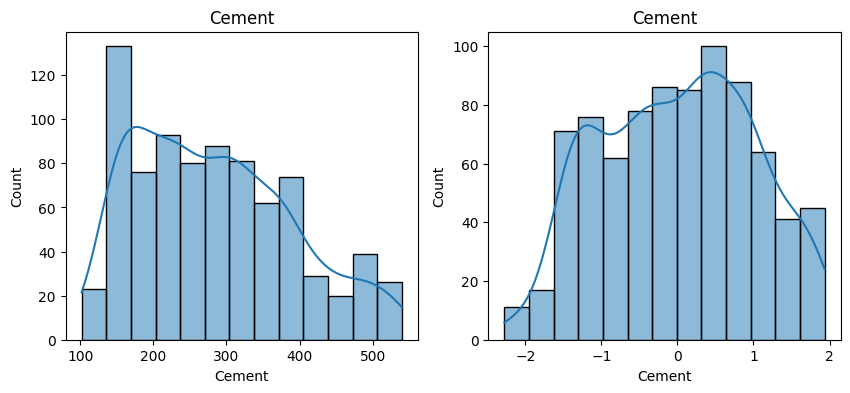

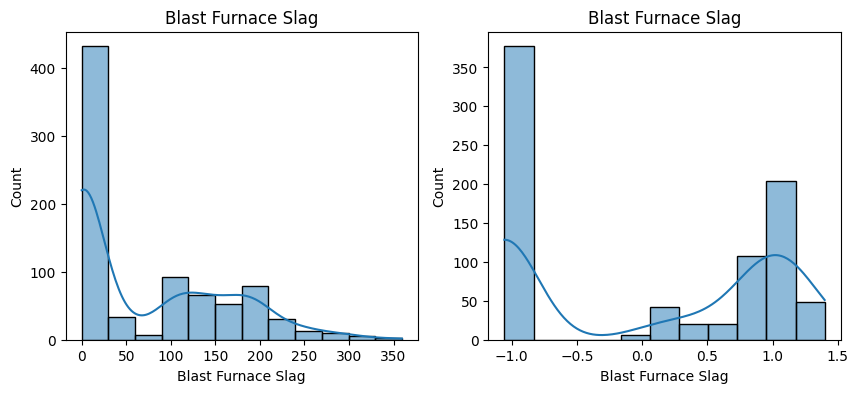

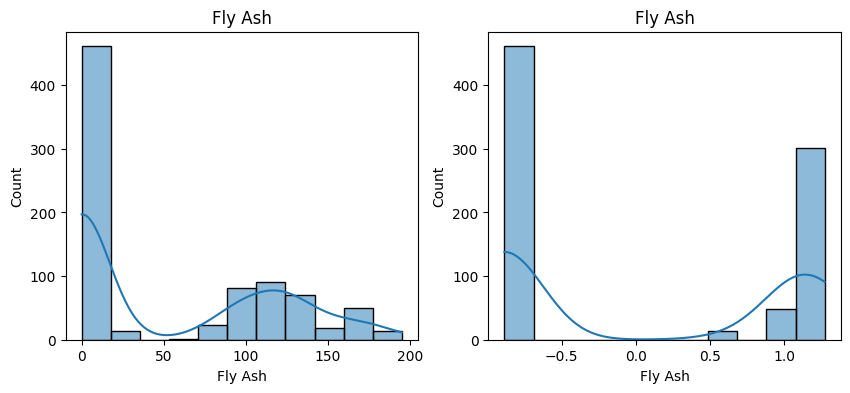

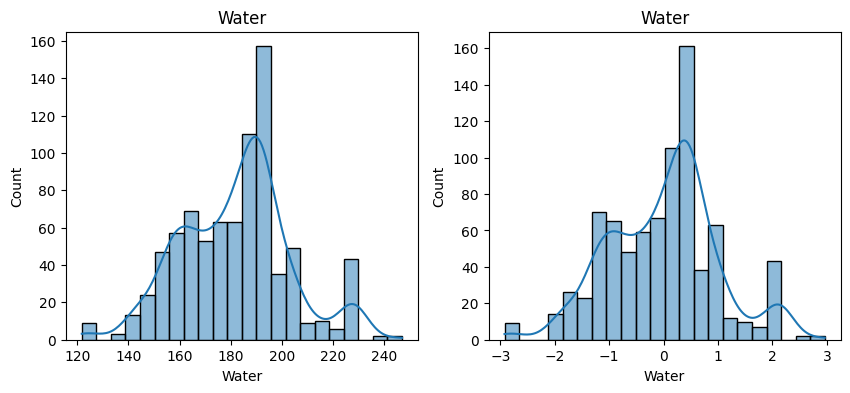

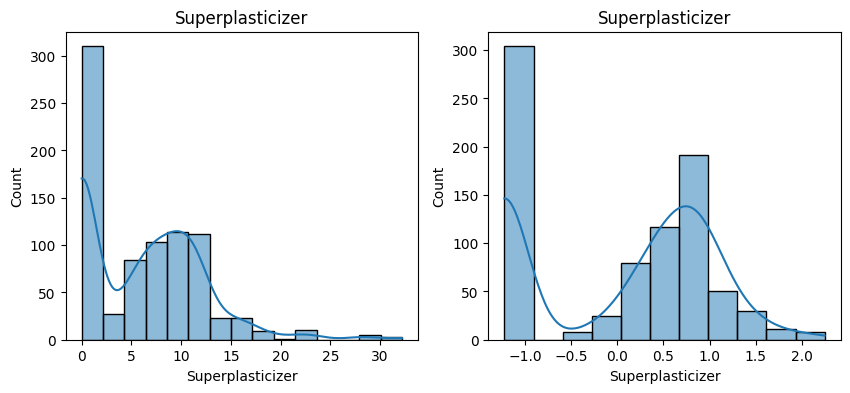

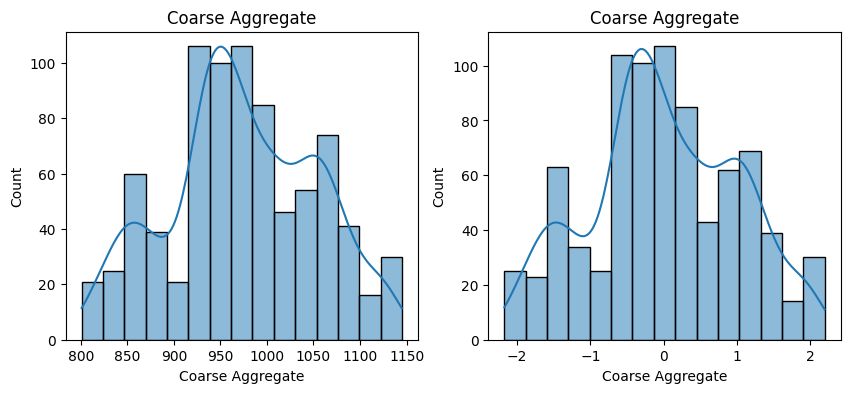

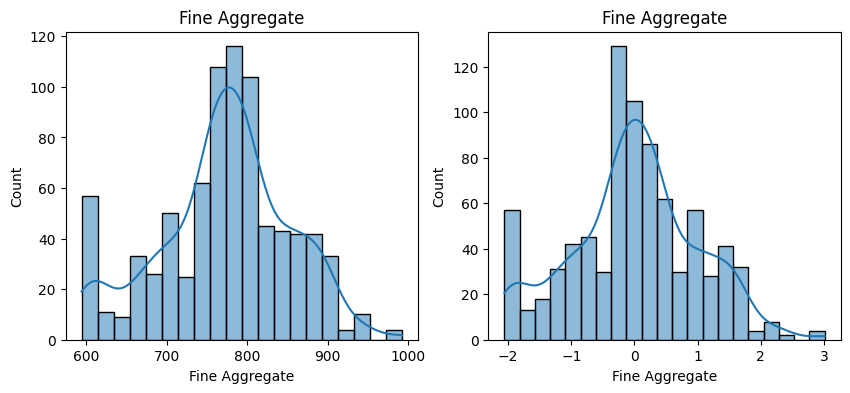

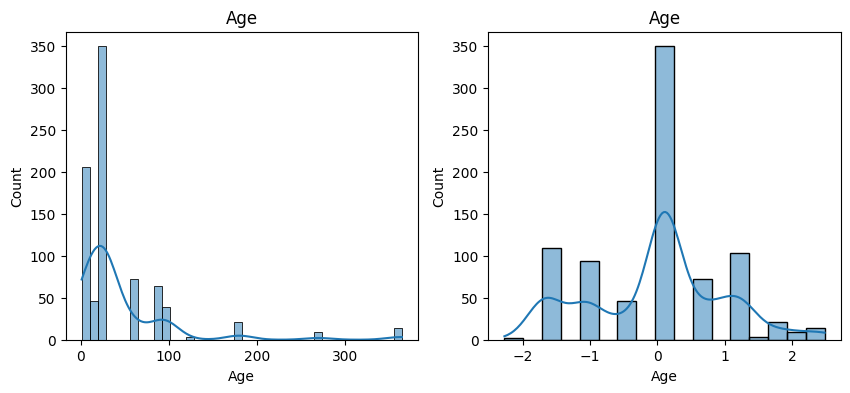

In [130]:
#before and after comparision of yeo johnson transformation
for cols in x_train_transformed2.columns:
  plt.figure(figsize=(10,4))
  plt.subplot(1,2,1)
  sns.histplot(x_train[cols],kde=True)
  plt.title(cols)

  plt.subplot(1,2,2)
  sns.histplot(x_train_transformed2[cols],kde=True)
  plt.title(cols)

  plt.show()

In [131]:
#side-by-side lambda
pd.DataFrame({'cols':x_train.columns,'box_cox_lambda':pt.lambdas_,'yeo_johnson_lambda':pt1.lambdas_})

,cols,box_cox_lambda,yeo_johnson_lambda
0,Cement,0.172271,0.169544
1,Blast Furnace Slag,0.025273,0.016633
2,Fly Ash,-0.032412,-0.136480
3,Water,0.809568,0.808438
4,Superplasticizer,0.099711,0.264160
5,Coarse Aggregate,1.129168,1.129395
6,Fine Aggregate,1.829625,1.830763
7,Age,0.048975,0.001771
